# 5 km protest-treatment map

This notebook has one purpose: generate `5km_plot.png` from the current protest-grid, AC, and grid files.

In [1]:
from pathlib import Path
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

PROJECT = Path(r"C:\Users\eunic\Dropbox\sa_fires\proj_bureaucrats_farms")
SHARED = PROJECT.parent
INTERMEDIATE = PROJECT / "data_output/intermediate"
OUTPUT = Path(r"C:\Users\eunic\OneDrive\Documents\GitHub\proj_bureaucrats_farms\figures\5km_plot.png")
OUTPUT.parent.mkdir(parents=True, exist_ok=True)

In [2]:
states = gpd.read_file(SHARED / "data/input/admin-data/india/IND_adm/IND_adm1.shp")
states = states.loc[states["NAME_1"].isin(["Bihar", "Uttar Pradesh", "Punjab", "Haryana"])]
acs = gpd.read_file(INTERMEDIATE / "_0_2_3_ACs_right_shapefile.shp")
grid = gpd.read_file(INTERMEDIATE / "1-grid-generation.shp").rename(columns={"unq_s__": "unique_small_grid_id"})
grid = grid[["unique_small_grid_id", "geometry"]].drop_duplicates("unique_small_grid_id")

intersection = pd.read_csv(INTERMEDIATE / "_1_AC_grid_intersection.csv")
protests = pd.read_csv(INTERMEDIATE / "8_grids_ac_pr_5km.csv").rename(columns={"unq_s__": "unique_small_grid_id"})
protests = protests.groupby("unique_small_grid_id", as_index=False)["protest_place"].max()
mapped = intersection.merge(protests, on="unique_small_grid_id", how="left")
mapped["protest_place"] = mapped["protest_place"].fillna(0)
mapped["treat"] = mapped["protest_place"].gt(0).astype(int)
mapped = gpd.GeoDataFrame(mapped.merge(grid, on="unique_small_grid_id", how="inner"), geometry="geometry", crs=grid.crs)

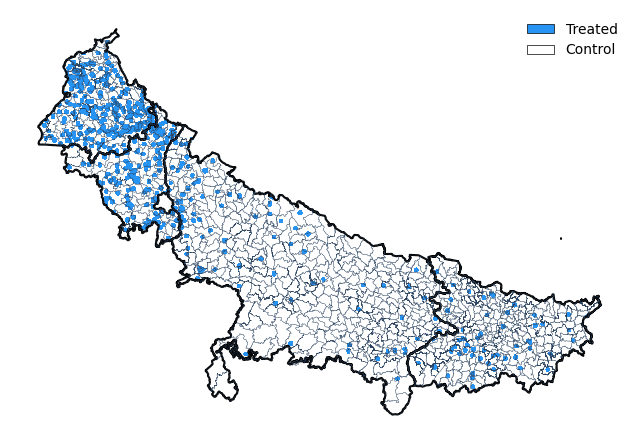

Saved C:\Users\eunic\OneDrive\Documents\GitHub\proj_bureaucrats_farms\figures\5km_plot.png


In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
states.boundary.plot(ax=ax, color="black")
acs.boundary.plot(ax=ax, color="#2C4460", linewidth=0.2)
mapped.plot(ax=ax, color=mapped["treat"].map({0: "white", 1: "#2793F2"}), edgecolor="none", linewidth=0)
ax.legend(handles=[
    mpatches.Patch(facecolor="#2793F2", edgecolor="black", linewidth=0.5, label="Treated"),
    mpatches.Patch(facecolor="white", edgecolor="black", linewidth=0.5, label="Control"),
], loc="upper right", frameon=False)
ax.set_axis_off()
fig.savefig(OUTPUT, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved {OUTPUT}")